# Rep. 4. Checkpoint 2. Estrategias I

Sara y Edgardo

In [1]:
# Si no tienes yfinance instalado, corre esto primero:


import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Funciones base:

In [2]:
def payoff_opcion(S, K, prima, tipo, posicion):
    if tipo == 'call':
        payoff = np.maximum(S - K, 0)
    elif tipo == 'put':
        payoff = np.maximum(K - S, 0)
    return posicion * (payoff - prima)


def payoff_estrategia(S, legs):
    total = np.zeros_like(S)
    for leg in legs:
        total += payoff_opcion(S, leg['K'], leg['prima'], leg['tipo'], leg['posicion'])
    return total


def graficar_estrategia(S, pnl, titulo, S0=None, K_lines=[]):
    plt.figure(figsize=(9,5))
    plt.plot(S, pnl, linewidth=2)
    plt.axhline(0, color='black', linestyle='--')

    if S0 is not None:
        plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')

    for K, label in K_lines:
        plt.axvline(K, linestyle=':', label=label)

    plt.title(titulo)
    plt.xlabel('$S_T$')
    plt.ylabel('P&L')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Descargamos los dattos reales de SPY y de los tickers:

In [3]:
ticker = yf.Ticker("SPY")

# Precio actual del subyacente
S0 = ticker.history(period="1d")["Close"].iloc[-1]

print(f"Precio actual SPY: {S0:.2f}")

# Ver vencimientos disponibles
expirations = ticker.options
print("\nVencimientos disponibles:")
print(expirations)

Precio actual SPY: 679.46

Vencimientos disponibles:
('2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-24', '2026-04-30', '2026-05-01', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-18', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


Cadena de opciones:

In [4]:
# Elegimos el vencimiento correcto
exp_date = "2026-04-17"

# Descargar opciones
opt = ticker.option_chain(exp_date)

calls = opt.calls
puts = opt.puts

print("Calls:")
display(calls.head())

print("\nPuts:")
display(puts.head())

Calls:


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260417C00300000,2026-04-08 14:14:13+00:00,300.0,375.28,378.20,381.01,0.0,0.0,1.0,8,2.187505,True,REGULAR,USD
1,SPY260417C00305000,2026-03-20 15:23:40+00:00,305.0,349.79,373.20,376.01,0.0,0.0,6.0,6,2.146489,True,REGULAR,USD
2,SPY260417C00310000,2026-03-23 17:53:26+00:00,310.0,348.26,368.20,371.02,0.0,0.0,NaN,6,2.113286,True,REGULAR,USD
3,SPY260417C00325000,2026-04-08 14:14:13+00:00,325.0,350.31,353.21,356.03,0.0,0.0,1.0,22,2.005864,True,REGULAR,USD
4,SPY260417C00330000,2026-04-09 15:32:52+00:00,330.0,348.10,348.22,351.03,0.0,0.0,1.0,3,1.974610,True,REGULAR,USD



Puts:


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260417P00300000,2026-04-10 20:05:42+00:00,300.0,0.01,0.0,0.01,0.0,0.0,7.0,41449,1.656252,False,REGULAR,USD
1,SPY260417P00305000,2026-04-01 18:50:11+00:00,305.0,0.01,0.0,0.01,0.0,0.0,186.0,3390,1.625002,False,REGULAR,USD
2,SPY260417P00310000,2026-04-02 19:47:29+00:00,310.0,0.01,0.0,0.01,0.0,0.0,1714.0,3129,1.593752,False,REGULAR,USD
3,SPY260417P00315000,2026-04-07 19:10:50+00:00,315.0,0.01,0.0,0.01,0.0,0.0,200.0,2118,1.562502,False,REGULAR,USD
4,SPY260417P00320000,2026-04-07 13:38:35+00:00,320.0,0.01,0.0,0.01,0.0,0.0,1000.0,8633,1.531252,False,REGULAR,USD


**Elegir strike ATM y calcular primas:**

In [5]:
# Encontrar strike más cercano al precio actual (ATM)
calls['dist'] = abs(calls['strike'] - S0)
atm_call = calls.loc[calls['dist'].idxmin()]

puts['dist'] = abs(puts['strike'] - S0)
atm_put = puts.loc[puts['dist'].idxmin()]

K = atm_call['strike']

# Precio mid
C = (atm_call['bid'] + atm_call['ask']) / 2
P = (atm_put['bid'] + atm_put['ask']) / 2

print(f"Strike ATM (K): {K}")
print(f"Call mid price: {C:.2f}")
print(f"Put mid price : {P:.2f}")

Strike ATM (K): 679.0
Call mid price: 5.96
Put mid price : 5.12


### Long Straddle (payoff diagram):

Costo total        : $11.08
Break-even sup.    : $690.08
Break-even inf.    : $667.92
Pérdida máxima     : $-11.08  (si ST =679.0)


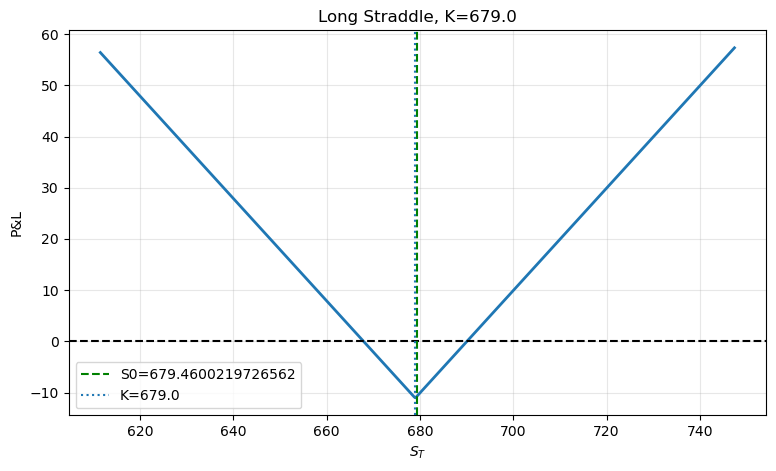

In [6]:
# Rango de precios posibles
S_range = np.linspace(S0*0.9, S0*1.1, 500)

# Long Straddle
legs_straddle = [
    {'tipo': 'call', 'K': K, 'prima': C, 'posicion': +1},
    {'tipo': 'put',  'K': K, 'prima': P, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_straddle)

# Métricas
print(f"Costo total        : ${C+P:.2f}")
print(f"Break-even sup.    : ${K+C+P:.2f}")
print(f"Break-even inf.    : ${K-C-P:.2f}")
print(f"Pérdida máxima     : ${-(C+P):.2f}  (si ST ={K})")

# Gráfica
graficar_estrategia(S_range, pnl, f'Long Straddle, K={K}', S0=S0,
                    K_lines=[(K, f'K={K}')])

Elegir strikes OTM (para strangle):

In [7]:
# Elegir strikes OTM (uno arriba y uno abajo del precio actual)

# Call OTM (arriba de S0)
call_otm = calls[calls['strike'] > S0].iloc[0]

# Put OTM (abajo de S0)
put_otm = puts[puts['strike'] < S0].iloc[-1]

K_call = call_otm['strike']
K_put  = put_otm['strike']

# Precios mid
C_otm = (call_otm['bid'] + call_otm['ask']) / 2
P_otm = (put_otm['bid'] + put_otm['ask']) / 2

print(f"K_call (OTM): {K_call}")
print(f"K_put  (OTM): {K_put}")
print(f"Call OTM mid: {C_otm:.2f}")
print(f"Put  OTM mid: {P_otm:.2f}")

K_call (OTM): 680.0
K_put  (OTM): 679.0
Call OTM mid: 5.36
Put  OTM mid: 5.12


### Long Strangle (payoff diagram):

Costo total        : $10.47
Break-even sup.    : $690.48
Break-even inf.    : $668.52


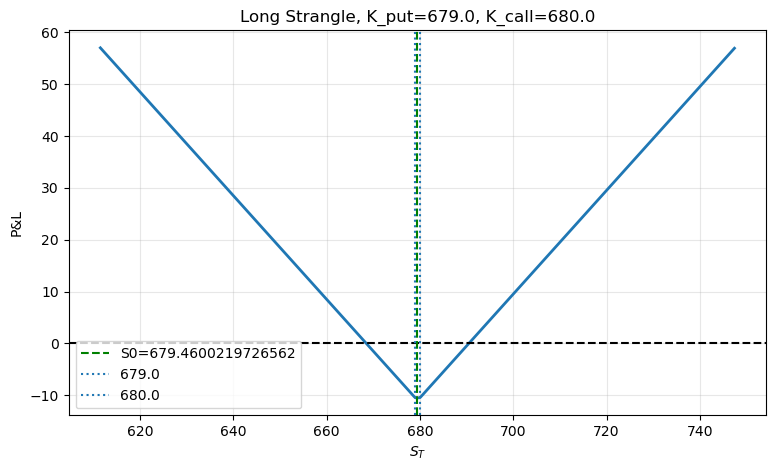

In [8]:
# Long Strangle
legs_strangle = [
    {'tipo': 'call', 'K': K_call, 'prima': C_otm, 'posicion': +1},
    {'tipo': 'put',  'K': K_put,  'prima': P_otm, 'posicion': +1},
]

pnl = payoff_estrategia(S_range, legs_strangle)

# Métricas
print(f"Costo total        : ${C_otm+P_otm:.2f}")
print(f"Break-even sup.    : ${K_call+C_otm+P_otm:.2f}")
print(f"Break-even inf.    : ${K_put-C_otm-P_otm:.2f}")

# Gráfica
graficar_estrategia(S_range, pnl,
                    f'Long Strangle, K_put={K_put}, K_call={K_call}',
                    S0=S0,
                    K_lines=[(K_put, f'{K_put}'), (K_call, f'{K_call}')])

Elegir strikes para Bull Call Spread:

In [9]:
# Strike bajo (ATM)
K1 = K
C1 = C

# Strike alto (el siguiente disponible arriba)
call_otm_2 = calls[calls['strike'] > K1].iloc[1]

K2 = call_otm_2['strike']
C2 = (call_otm_2['bid'] + call_otm_2['ask']) / 2

print(f"K1 (long call): {K1}")
print(f"K2 (short call): {K2}")
print(f"Prima call comprada: {C1:.2f}")
print(f"Prima call vendida : {C2:.2f}")

K1 (long call): 679.0
K2 (short call): 681.0
Prima call comprada: 5.96
Prima call vendida : 4.79


### Bull Call Spread (payoff diagram):

Prima neta pagada  : $1.18
Ganancia máxima    : $0.82  (si ST ≥ 681.0)
Pérdida máxima     : $-1.18  (si ST ≤ 679.0)
Break-even         : $680.18


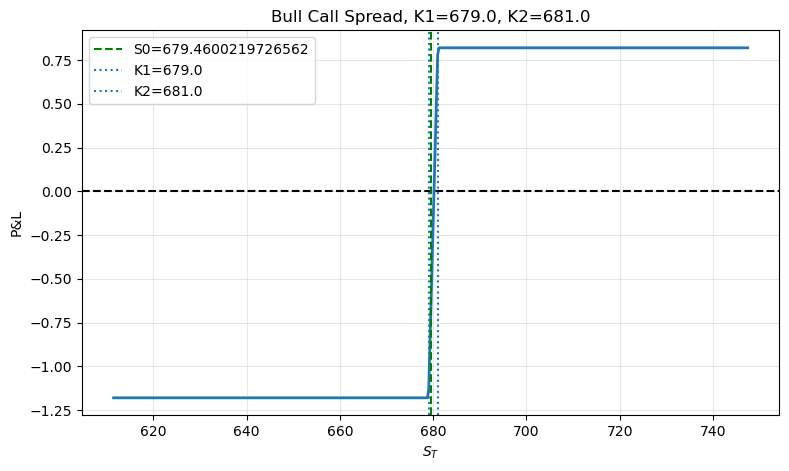

In [10]:
# Bull Call Spread
legs_bull = [
    {'tipo': 'call', 'K': K1, 'prima': C1, 'posicion': +1},  # compras call
    {'tipo': 'call', 'K': K2, 'prima': C2, 'posicion': -1},  # vendes call
]

pnl = payoff_estrategia(S_range, legs_bull)

# Prima neta
prima_neta = C1 - C2

# Métricas
print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K2-K1)-prima_neta:.2f}  (si ST ≥ {K2})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≤ {K1})")
print(f"Break-even         : ${K1+prima_neta:.2f}")

# Gráfica
graficar_estrategia(S_range, pnl,
                    f'Bull Call Spread, K1={K1}, K2={K2}',
                    S0=S0,
                    K_lines=[(K1, f'K1={K1}'), (K2, f'K2={K2}')])

Bear Put Spread (elegir strikes):

In [11]:
# Strike alto (ATM)
K1_put = K
P1 = P

# Strike bajo (OTM abajo)
put_otm_2 = puts[puts['strike'] < K1_put].iloc[-2]

K2_put = put_otm_2['strike']
P2 = (put_otm_2['bid'] + put_otm_2['ask']) / 2

print(f"K1 (long put): {K1_put}")
print(f"K2 (short put): {K2_put}")
print(f"Prima put comprada: {P1:.2f}")
print(f"Prima put vendida : {P2:.2f}")

K1 (long put): 679.0
K2 (short put): 677.0
Prima put comprada: 5.12
Prima put vendida : 4.39


### Bear Put Spread (payoff diagram):

Prima neta pagada  : $0.72
Ganancia máxima    : $1.28  (si ST ≤ 677.0)
Pérdida máxima     : $-0.72  (si ST ≥ 679.0)
Break-even         : $678.28


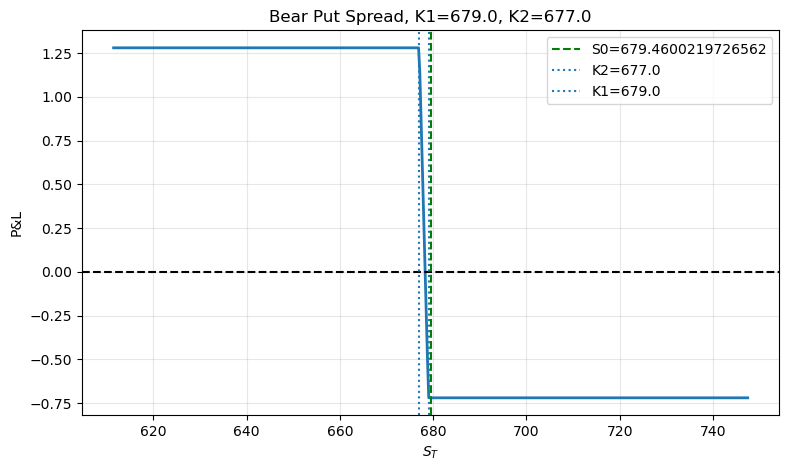

In [12]:
# Bear Put Spread
legs_bear = [
    {'tipo': 'put', 'K': K1_put, 'prima': P1, 'posicion': +1},  # compras put
    {'tipo': 'put', 'K': K2_put, 'prima': P2, 'posicion': -1},  # vendes put
]

pnl = payoff_estrategia(S_range, legs_bear)

# Prima neta
prima_neta = P1 - P2

# Métricas
print(f"Prima neta pagada  : ${prima_neta:.2f}")
print(f"Ganancia máxima    : ${(K1_put-K2_put)-prima_neta:.2f}  (si ST ≤ {K2_put})")
print(f"Pérdida máxima     : ${-prima_neta:.2f}  (si ST ≥ {K1_put})")
print(f"Break-even         : ${K1_put-prima_neta:.2f}")

# Gráfica
graficar_estrategia(S_range, pnl,
                    f'Bear Put Spread, K1={K1_put}, K2={K2_put}',
                    S0=S0,
                    K_lines=[(K2_put, f'K2={K2_put}'), (K1_put, f'K1={K1_put}')])

## **Preguntas**

**1. ¿Cuál está más cerca de su pérdida máxima?**

Con S₀ ≈ 679, el long straddle es el más cercano a su pérdida máxima porque esta ocurre cuando el precio queda en el strike, que coincide casi con el nivel actual. Esto indica que el mercado no se ha movido aún y que la estrategia apuesta a un movimiento fuerte futuro.

**2. Straddle vs Strangle**

El straddle cuesta 11.08 y el strangle 10.47, por lo que el strangle es 0.61 más barato. Sin embargo, el strangle requiere un movimiento mayor para ser rentable, ya que sus break-evens están más alejados del precio actual.

**3. Comprar straddle con IV alta**

Si compras un straddle con IV alta, puede no ser buena estrategia porque las opciones están caras. Después del evento, la IV suele bajar, lo que puede generar pérdidas aunque el precio se mueva.

**4. ¿Por qué usar bull spread?**
Se usa para reducir el costo y el riesgo. Además, es útil cuando se espera una subida moderada, ya que no necesitas pagar por una ganancia ilimitada.

**5. ¿Cerrar antes del vencimiento?**

Si SPY supera K2 antes del vencimiento, suele ser conveniente cerrar la posición porque ya se alcanzó casi la ganancia máxima. También se considera el riesgo de que el precio regrese.

**6. Impacto de la IV**

El straddle es más sensible a la IV porque tiene vega positiva alta. El bull spread es menos sensible, ya que la opción vendida compensa parte de ese efecto.

**7. Griegas: call vs bull spread**

El bull spread reduce la exposición a las griegas comparado con un call simple. La diferencia más importante está en la vega, que es mucho menor en el spread.